<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab8/Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 8**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install -q pmdarima

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

## **Pregunta 1**

(a) Genera un proceso ruido blanco, $\epsilon_t\sim N(0,1)$.

In [ ]:
# Generación del Proceso de Ruido Blanco
np.random.seed(42)
n_obs = 250
ruido_blanco = np.random.normal(loc=0, scale=1, size=n_obs)
# ruido_blanco = np.random.uniform(low= -1 , high= 1, size=n_obs)

# Crear Serie con índice numérico por defecto (0 a 499)
df_rb = pd.Series(ruido_blanco, name="Ruido_Blanco")

(b) Grafica la serie del ruido blanco, la función de autocorrelación y autocorrelación parcial.

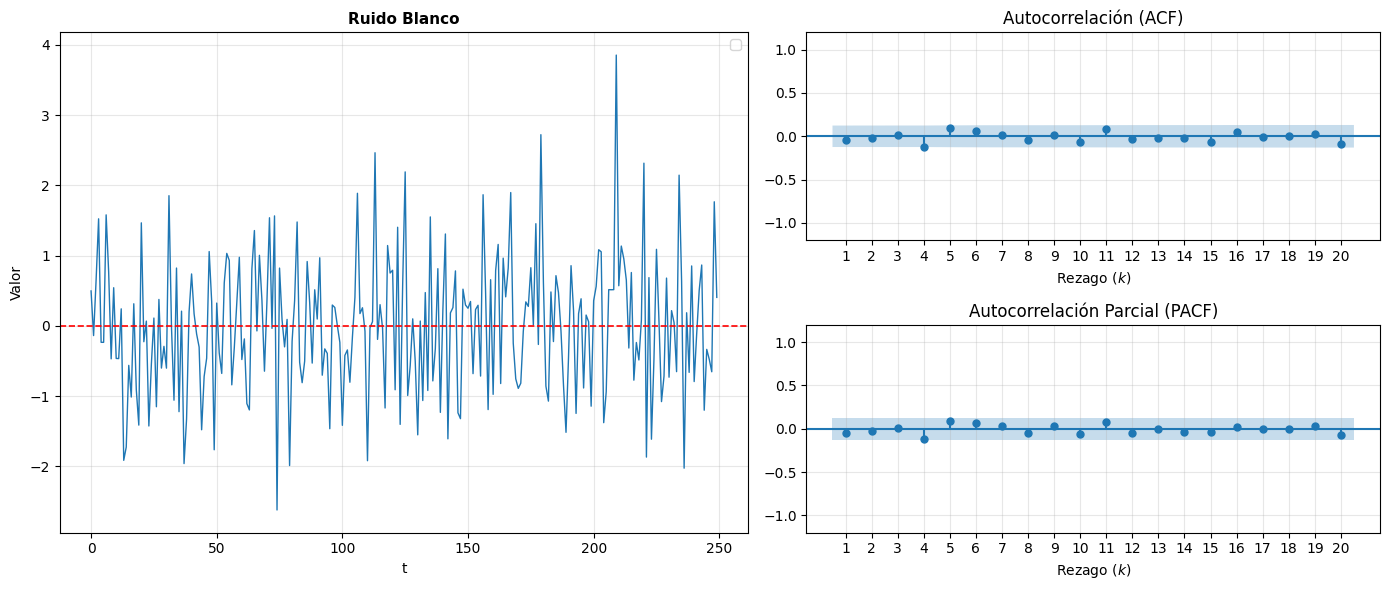

In [ ]:
# Gráficos
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

lags_mostrar = 20

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(df_rb.index, df_rb.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Ruido Blanco", fontsize=11, fontweight="bold")
ax1.set_xlabel("t")  # En lugar de "Fecha"
ax1.set_ylabel("Valor")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): ACF
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(df_rb, ax=ax2, lags=20, zero=False,  title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)


# COLUMNA 2 (inferior): PACF
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(df_rb, ax=ax3, lags=20, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie de ruido blanco es estacionaria. Usa un nivel de significancia de 5%

In [ ]:
# Aplicar el test Dickey-Fuller Aumentado
resultado_adf = adfuller(df_rb)

print('Resultados del Test Dickey-Fuller Aumentado:')
print(f'Estadístico ADF: {resultado_adf[0]:.4f}')
print(f'Valor p: {resultado_adf[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf[1] <= 0.05:
    print('La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado:
Estadístico ADF: -16.5008
Valor p: 0.0000
Valores críticos:
   1%: -3.4569
   5%: -2.8732
   10%: -2.5730
La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


## **Pregunta 2**

(a) Simula el siguiente proceso AR(1):

$$y_t=0.8y_{t-1}+\epsilon_t$$

In [ ]:
# 1. Simulación del proceso AR(1):
# np.random.seed(1042)
n_obs = 250
e = np.random.normal(loc=0, scale=1, size=n_obs)
y = np.zeros(n_obs)

# Construcción recursiva de la serie
y[0] = e[0]
for t in range(1, n_obs):
    y[t] = 0.8*y[t - 1] + e[t]

# Crear Serie con índice numérico secuencial (sin fechas)
serie_ar1 = pd.Series(y, name="AR1_Estacionario")


(b) Grafica la serie del AR(1), la función de autocorrelación y autocorrelación parcial.

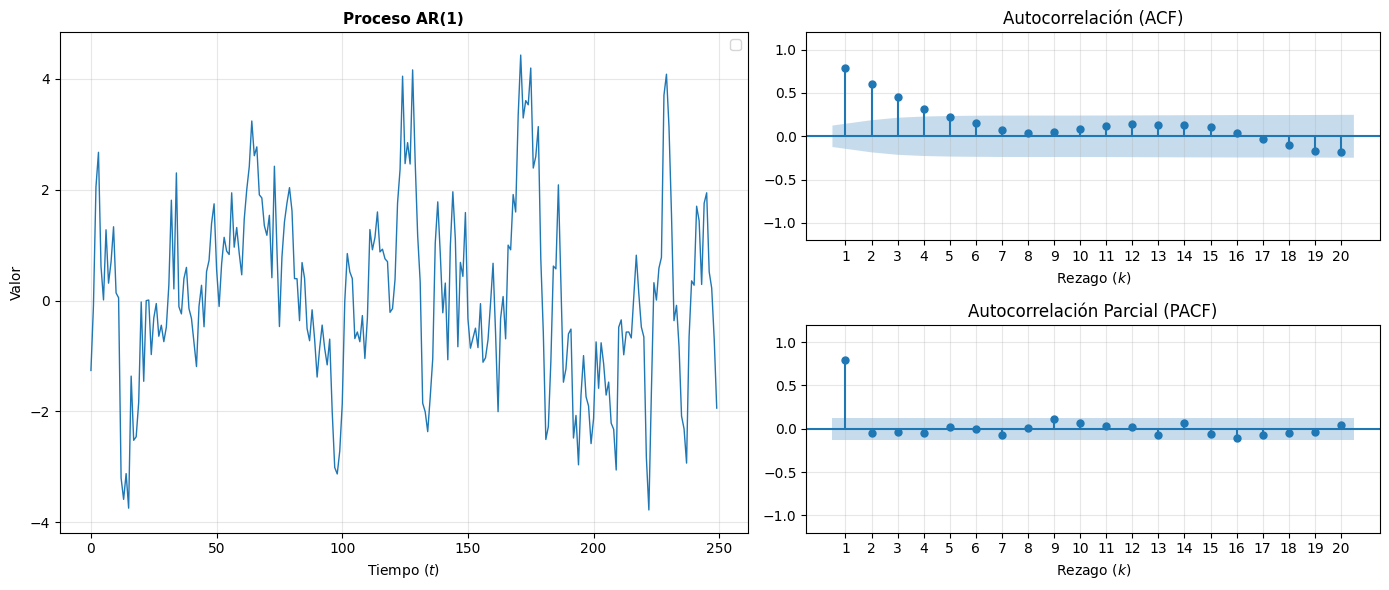

In [ ]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_ar1.index, serie_ar1.values, color="#1f77b4", linewidth=1)
# ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(
    r"Proceso AR(1)",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_ar1, ax=ax2, lags=20, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_ar1, ax=ax3, lags=20, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie AR(1) es estacionaria. Usa un nivel de significancia de 5%

In [ ]:
resultado_adf_ar1 = adfuller(serie_ar1)

print('Resultados del Test Dickey-Fuller Aumentado para la serie AR(1):')
print(f'Estadístico ADF: {resultado_adf_ar1[0]:.4f}')
print(f'Valor p: {resultado_adf_ar1[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_ar1[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_ar1[1] <= 0.05:
    print('La serie AR(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie AR(1) no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie AR(1):
Estadístico ADF: -5.2905
Valor p: 0.0000
Valores críticos:
   1%: -3.4569
   5%: -2.8732
   10%: -2.5730
La serie AR(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


(d) Repite las preguntas (a), (b) y (c) para los siguientes procesos:

(i) $y_t=0.5 + 0.8y_{t-1}+\epsilon_t$

(ii) $y_t=1.03y_{t-1}+\epsilon_t$

(iii) $y_t=y_{t-1}+\epsilon_t$

(iv) $y_t=0.05+y_{t-1}+\epsilon_t$


## **Pregunta 3**

(a) Simula el siguiente proceso MA(1):

$$y_t=\epsilon_t+0.5\epsilon_{t-1}$$
donde $\epsilon_t \sim N(0,1)$.

In [ ]:
# 1. Simulación del proceso MA(1): y_t = epsilon_t + 0.5*epsilon_{t-1}
n_obs = 250
np.random.seed(42) # Para reproducibilidad
epsilon = np.random.normal(loc=0, scale=1, size=n_obs)

y_ma1 = np.zeros(n_obs)

# Construcción de la serie MA(1)
# El primer término y[0] solo depende de epsilon[0] (asumiendo epsilon[-1]=0)
y_ma1[0] = epsilon[0]
for t in range(1, n_obs):
    y_ma1[t] = epsilon[t] + 0.6 * epsilon[t-1]

# Crear Serie con índice numérico secuencial
serie_ma1 = pd.Series(y_ma1, name="MA1_Estacionario")

(b) Grafica la serie del MA(1), la función de autocorrelación y autocorrelación parcial.

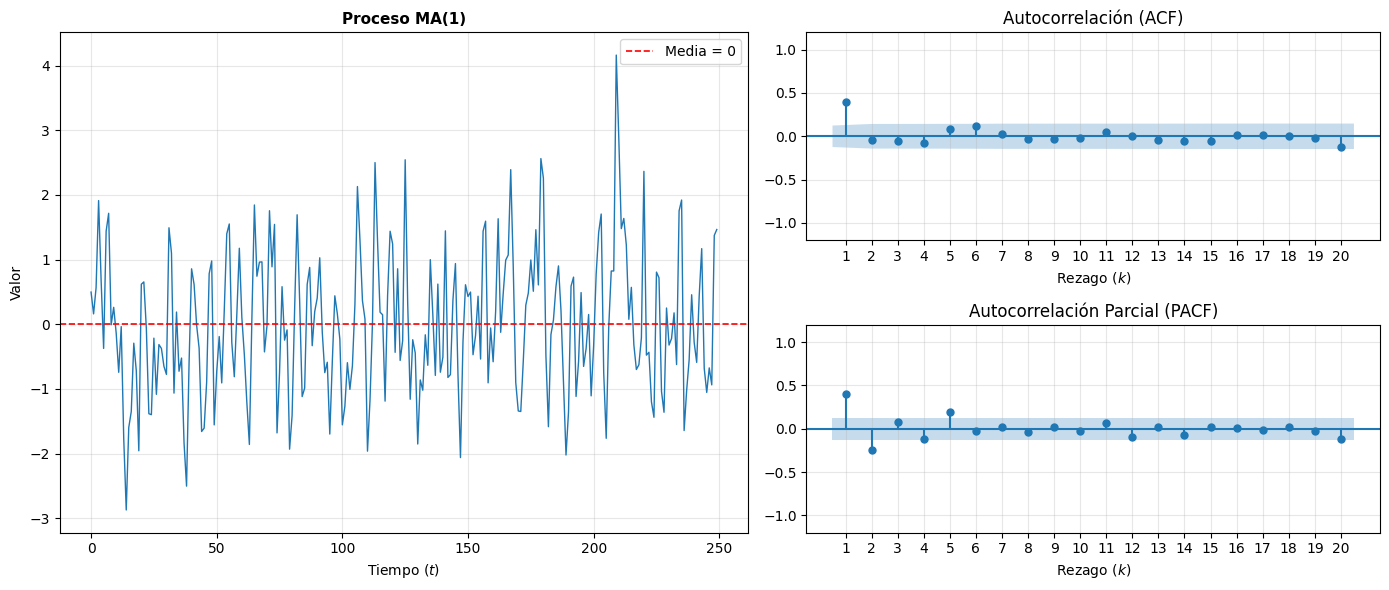

In [ ]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_ma1.index, serie_ma1.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2, label="Media = 0")
ax1.set_title(
    r"Proceso MA(1)",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_ma1, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_ma1, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie MA(1) es estacionaria. Usa un nivel de significancia de 5%

In [ ]:
resultado_adf_ma1 = adfuller(serie_ma1)

print('Resultados del Test Dickey-Fuller Aumentado para la serie MA(1):')
print(f'Estadístico ADF: {resultado_adf_ma1[0]:.4f}')
print(f'Valor p: {resultado_adf_ma1[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_ma1[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_ma1[1] <= 0.05:
    print('La serie MA(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie MA(1) no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie MA(1):
Estadístico ADF: -5.9531
Valor p: 0.0000
Valores críticos:
   1%: -3.4573
   5%: -2.8734
   10%: -2.5731
La serie MA(1) es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


## **Pregunta 4**

(a) Simula un proceso con una tendencia determinista:

$$y_t = 5 + 0.2t + \epsilon_t$$
donde $\epsilon_t \sim N(0,1)$.

In [ ]:
# 1. Simulación de un proceso con tendencia determinista: y_t = 5 + 0.2*t + epsilon_t
n_obs = 250
np.random.seed(42) # Para reproducibilidad
epsilon = np.random.normal(loc=0, scale=1, size=n_obs)

t = np.arange(n_obs) # Generar los valores de tiempo t
y_trend = 5 + 0.2 * t + epsilon

# Crear Serie con índice numérico secuencial
serie_trend = pd.Series(y_trend, name="Serie_con_Tendencia")

(b) Grafica la serie con tendencia determinista, la función de autocorrelación y autocorrelación parcial.

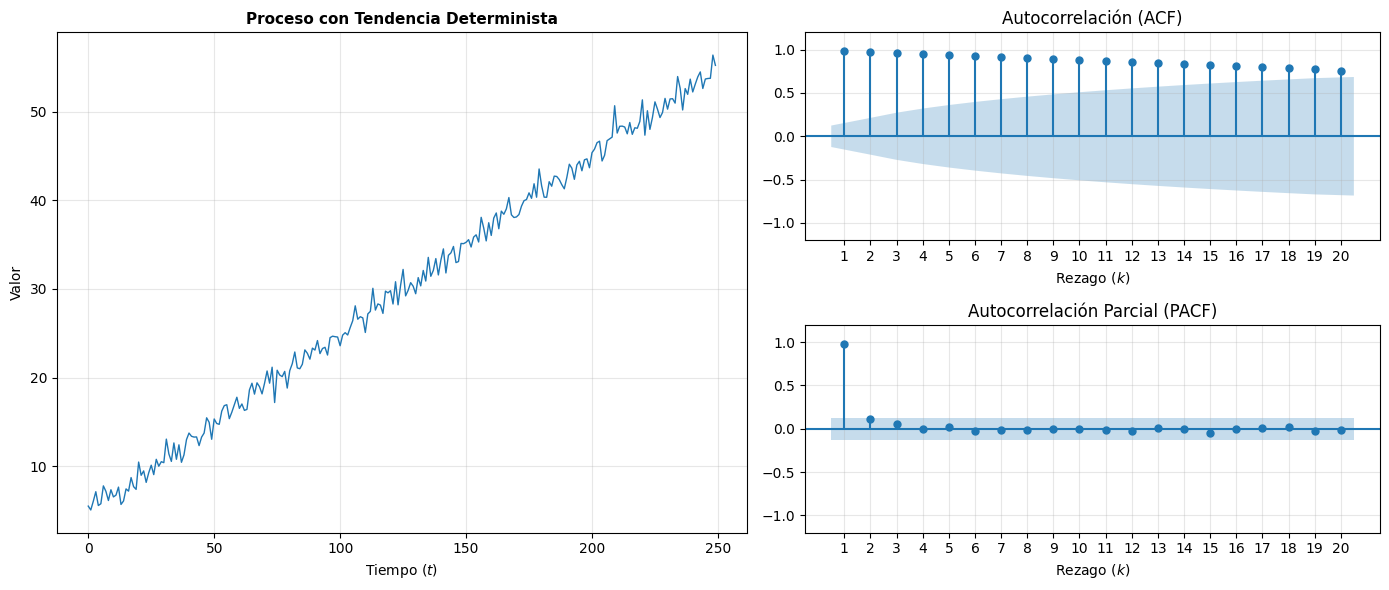

In [ ]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_trend.index, serie_trend.values, color="#1f77b4", linewidth=1)
ax1.set_title(
    r"Proceso con Tendencia Determinista",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_trend, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_trend, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie con tendencia determinista es estacionaria. Usa un nivel de significancia de 5%

In [ ]:
resultado_adf_trend = adfuller(serie_trend)

print('Resultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista:')
print(f'Estadístico ADF: {resultado_adf_trend[0]:.4f}')
print(f'Valor p: {resultado_adf_trend[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_trend[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_trend[1] <= 0.05:
    print('La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista:
Estadístico ADF: 0.2454
Valor p: 0.9747
Valores críticos:
   1%: -3.4580
   5%: -2.8737
   10%: -2.5733
La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).


(d) Aplica primeras diferencias para remover tendencia ¿Es la serie resultante estacionaria?


Resultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista (diferenciada):
Estadístico ADF: -8.5950
Valor p: 0.0000
Valores críticos:
   1%: -3.4580
   5%: -2.8737
   10%: -2.5733
La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


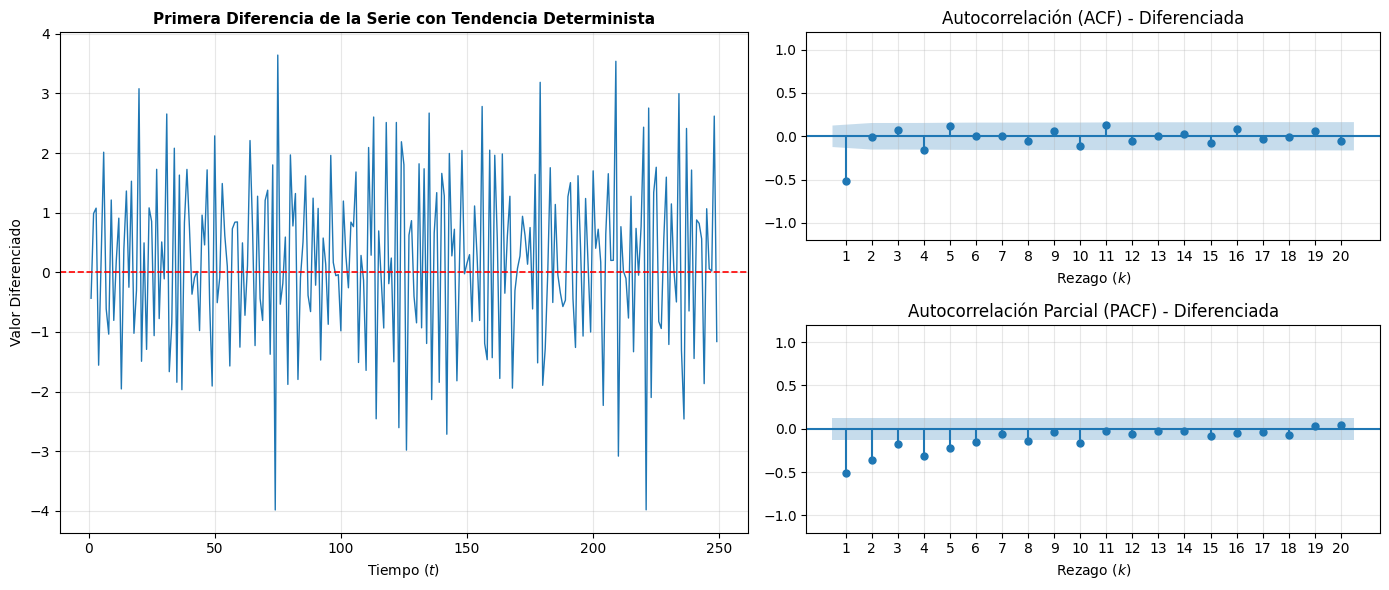

In [ ]:
# Aplicar la primera diferencia para remover la tendencia
serie_trend_diff = serie_trend.diff().dropna()

# Realizar el test ADF a la serie diferenciada
resultado_adf_trend_diff = adfuller(serie_trend_diff)

print('\nResultados del Test Dickey-Fuller Aumentado para la serie con Tendencia Determinista (diferenciada):')
print(f'Estadístico ADF: {resultado_adf_trend_diff[0]:.4f}')
print(f'Valor p: {resultado_adf_trend_diff[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_trend_diff[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_trend_diff[1] <= 0.05:
    print('La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie diferenciada no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

# Graficar la serie diferenciada, ACF y PACF para confirmación visual
lags_mostrar = 20

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_trend_diff.index, serie_trend_diff.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Primera Diferencia de la Serie con Tendencia Determinista", fontsize=11, fontweight="bold")
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor Diferenciado")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_trend_diff, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Diferenciada")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(serie_trend_diff, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Diferenciada", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Pregunta 5**

(a) Simula un proceso de **camino aleatorio** (random walk):

$$y_t = y_{t-1} + \epsilon_t$$

donde $\epsilon_t \sim N(0,1)$ y $y_0 = 0$.

In [ ]:
# 1. Simulación de un proceso de camino aleatorio: y_t = y_{t-1} + epsilon_t
n_obs = 250
# np.random.seed(3456) # Para reproducibilidad
epsilon_rw = np.random.normal(loc=0, scale=1, size=n_obs)

y_rw = np.zeros(n_obs)
y_rw[0] = 0 # y_0 = 0

for t in range(1, n_obs):
    y_rw[t] = y_rw[t-1] + epsilon_rw[t]

# Crear Serie con índice numérico secuencial
serie_rw = pd.Series(y_rw, name="Camino_Aleatorio")

(b) Grafica la serie del camino aleatorio, la función de autocorrelación y autocorrelación parcial.

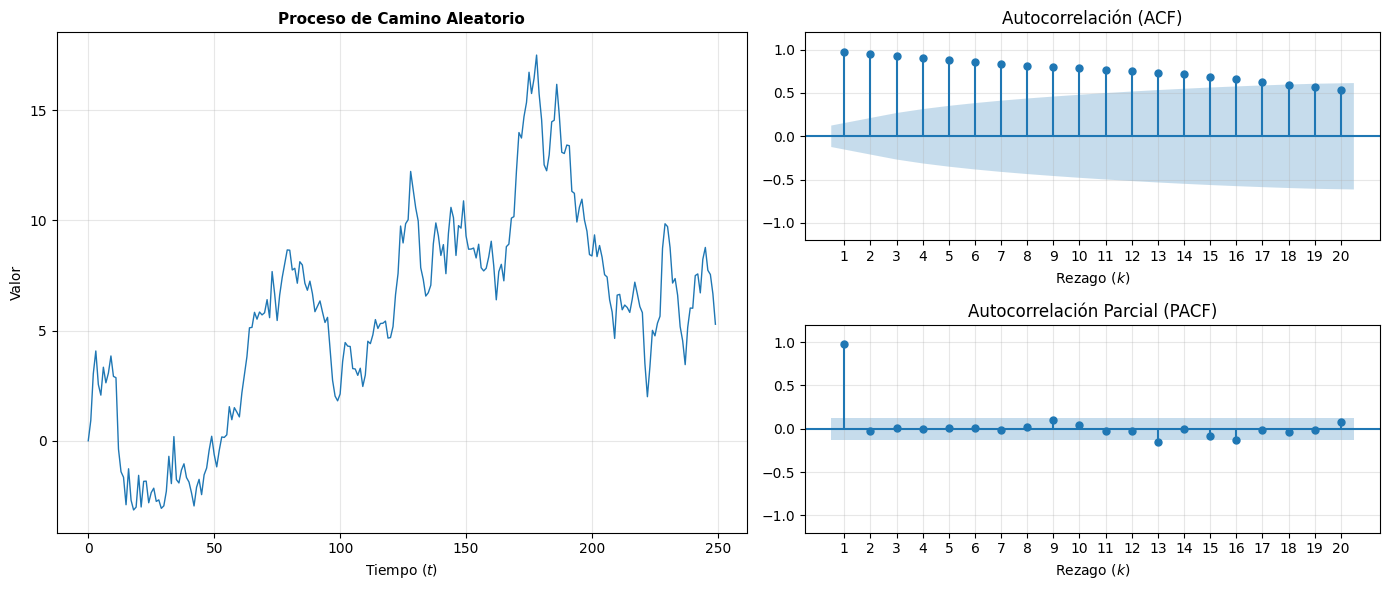

In [ ]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_rw.index, serie_rw.values, color="#1f77b4", linewidth=1)
ax1.set_title(
    r"Proceso de Camino Aleatorio",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_rw, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF)")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_rw, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF)", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie del paseo aleatorio es estacionaria. Usa un nivel de significancia de 5%.

In [ ]:
resultado_adf_rw = adfuller(serie_rw)

print('Resultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio:')
print(f'Estadístico ADF: {resultado_adf_rw[0]:.4f}')
print(f'Valor p: {resultado_adf_rw[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_rw[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_rw[1] <= 0.05:
    print('La serie es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio:
Estadístico ADF: -1.9008
Valor p: 0.3317
Valores críticos:
   1%: -3.4569
   5%: -2.8732
   10%: -2.5730
La serie no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).


(d) Aplica primeras diferencias al camino aleatorio. Grafica la serie resultante, su ACF y PACF, y testea su estacionariedad con un nivel de significancia de 5%.


Resultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio (diferenciado):
Estadístico ADF: -14.9632
Valor p: 0.0000
Valores críticos:
   1%: -3.4570
   5%: -2.8733
   10%: -2.5730
La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


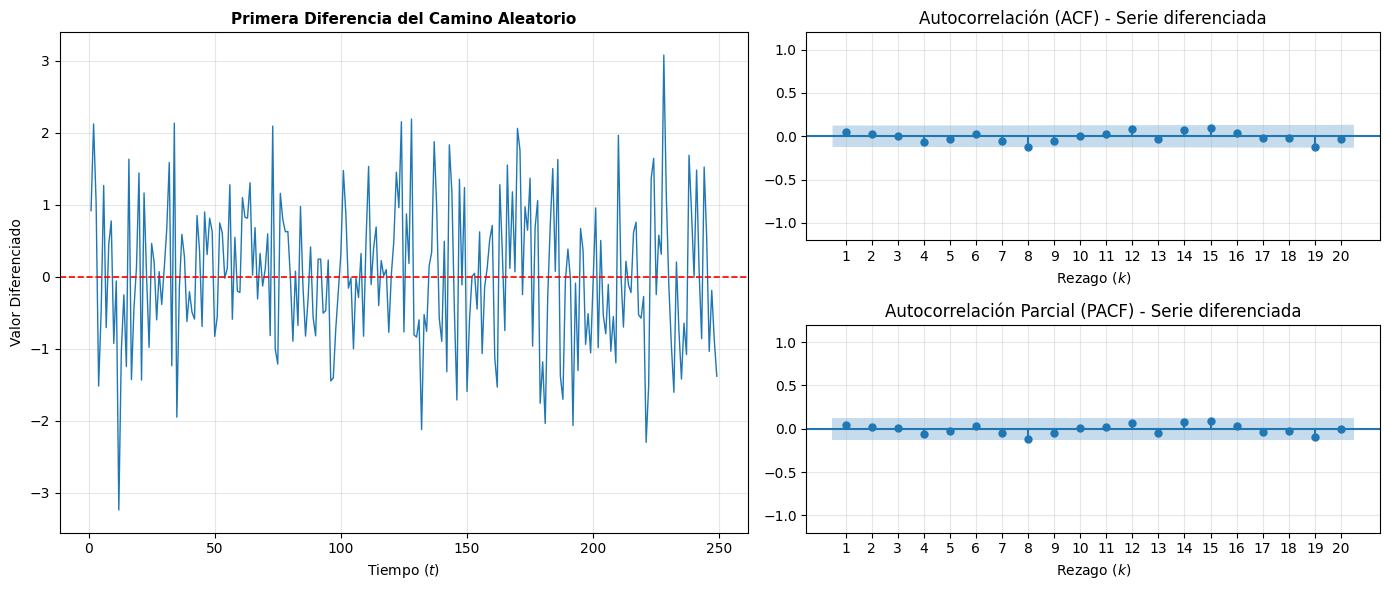

In [ ]:
# 1. Aplicar la primera diferencia
serie_rw_diff = serie_rw.diff().dropna()

# 2. Realizar el test ADF a la serie diferenciada
resultado_adf_rw_diff = adfuller(serie_rw_diff)

print('\nResultados del Test Dickey-Fuller Aumentado para el Camino Aleatorio (diferenciado):')
print(f'Estadístico ADF: {resultado_adf_rw_diff[0]:.4f}')
print(f'Valor p: {resultado_adf_rw_diff[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_rw_diff[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_rw_diff[1] <= 0.05:
    print('La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie diferenciada no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

# Graficar la serie diferenciada, ACF y PACF para confirmación visual
lags_mostrar = 20

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_rw_diff.index, serie_rw_diff.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Primera Diferencia del Camino Aleatorio", fontsize=11, fontweight="bold")
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor Diferenciado")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_rw_diff, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Serie diferenciada")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(serie_rw_diff, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Serie diferenciada", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(d) Si el precio de una acción sigue un paseo aleatorio ¿Por qué la mejor predicción para el precio a 10 días es el precio de hoy?

Un paseo aleatorio puro se define como:

$$P_t = P_{t-1} + \epsilon_t$$

donde $\epsilon_t$ es ruido blanco con $E[\epsilon_t] = 0$ y no correlacionado con la información pasada. Expresando el precio a 10 días ($P_{t+10}$) en función del precio actual observatorio ($P_t$):

$$P_{t+10} = P_t + \sum_{i=1}^{10} \epsilon_{t+i} = P_t + \epsilon_{t+1} + \epsilon_{t+2} + \dots + \epsilon_{t+10}$$

Aplicando la esperanza condicional:

$$E[P_{t+10} \mid \mathcal{F}_t] = E[P_t \mid \mathcal{F}_t] + \sum_{i=1}^{10} \underbrace{E[\epsilon_{t+i} \mid \mathcal{F}_t]}_{= 0}$$

$$\hat{P}_{t+10\vert{}t} = P_t$$

Notar que toda la información del pasado ya está descontada en $P_t$. Como los shocks futuros ($\epsilon_{t+1}, \dots, \epsilon_{t+10}$) representan noticias que aún no suceden, su valor esperado es $0$.

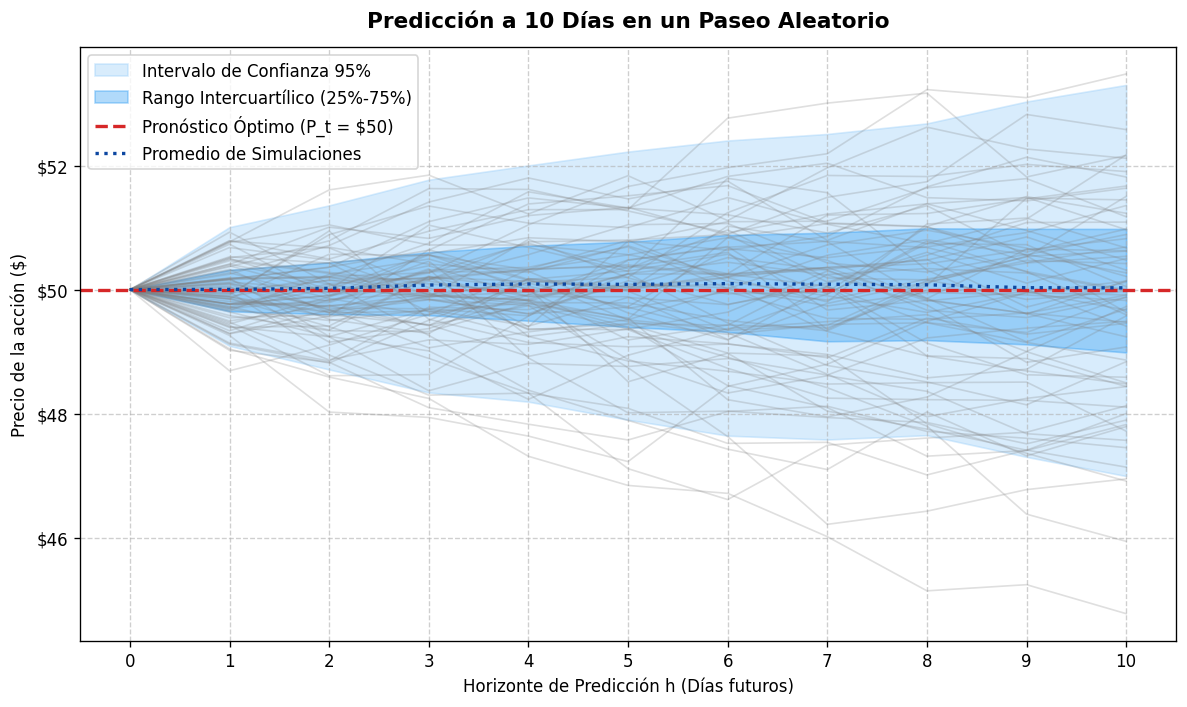

In [72]:
import matplotlib.ticker as ticker

# Parámetros
np.random.seed(42)
P0 = 50         # Precio actual del activo
sigma_daily = 0.5   # Volatilidad diaria ($)
horizon = 10        # Horizonte de proyección (10 días)
n_simulations = 500 # Número de trayectorias posibles para el precio

# Simulación: P_{t+h} = P_t + sum(epsilon)
shocks = np.random.normal(0, sigma_daily, size=(horizon, n_simulations))
price_paths = np.zeros((horizon + 1, n_simulations))  # Matriz para guardar precios: 11 filas x 500 columnas
price_paths[0] = P0

for t in range(1, horizon + 1):
    price_paths[t] = price_paths[t - 1] + shocks[t - 1]

# Cálculo de métricas por cada día
days = np.arange(0, horizon + 1)
mean_path = np.mean(price_paths, axis=1)
p2_5 = np.percentile(price_paths, 2.5, axis=1)
p5 = np.percentile(price_paths, 5, axis=1)
p25 = np.percentile(price_paths, 25, axis=1)
p75 = np.percentile(price_paths, 75, axis=1)
p95 = np.percentile(price_paths, 95, axis=1)
p97_5 = np.percentile(price_paths, 97.5, axis=1)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Muestra de trayectorias posibles (primeras 75)
ax.plot(days, price_paths[:, :75], color='gray', alpha=0.25, linewidth=1)    # Número de trayectorias que se grafican

# Abanico de incertidumbre (Intervalos de confianza)
ax.fill_between(days, p2_5, p97_5, color='#90caf9', alpha=0.35, label='Intervalo de Confianza 95%')
ax.fill_between(days, p25, p75, color='#2196f3', alpha=0.35, label='Rango Intercuartílico (25%-75%)')

# Línea de pronóstico óptimo (Precio de hoy constante)
ax.axhline(P0, color='#d62728', linestyle='--', linewidth=2, label=f'Pronóstico Óptimo (P_t = ${P0:.0f})')
ax.plot(days, mean_path, color='#0d47a1', linestyle=':', linewidth=2, label='Promedio de Simulaciones')

# Formato y estilo
ax.set_title("Predicción a 10 Días en un Paseo Aleatorio", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Horizonte de Predicción h (Días futuros)", fontsize=10)
ax.set_ylabel("Precio de la acción ($)", fontsize=10)
ax.set_xticks(days)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:.0f}'))
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## **Pregunta 6**

(a) Simula el siguiente proceso:

$$Y_t = 1.7 Y_{t-1} - 0.5 Y_{t-2} - 0.2 Y_{t-3} + \epsilon_t$$

donde $\epsilon_t \sim N(0,1)$.



In [ ]:
n_obs = 500
# np.random.seed(289) # Para reproducibilidad
epsilon_arima = np.random.normal(loc=0, scale=1, size=n_obs)

# Simulación directa del proceso:
y_arima = np.zeros(n_obs)

y_arima[0] = epsilon_arima[0]

if n_obs > 1:
    y_arima[1] = 1.7 * y_arima[0] + epsilon_arima[1]

if n_obs > 2:
    y_arima[2] = 1.7 * y_arima[1] - 0.5 * y_arima[0] + epsilon_arima[2]

# Para t >= 3
for t in range(3, n_obs):
    y_arima[t] = 1.7 * y_arima[t-1] + \
                 -0.5 * y_arima[t-2] - \
                 0.2 * y_arima[t-3] + epsilon_arima[t]

# Crear Serie con índice numérico secuencial
serie_arima = pd.Series(y_arima, name="ARIMA")

(b) Grafica la serie de tiempo, su función de autocorrelación (ACF) y autocorrelación parcial (PACF).

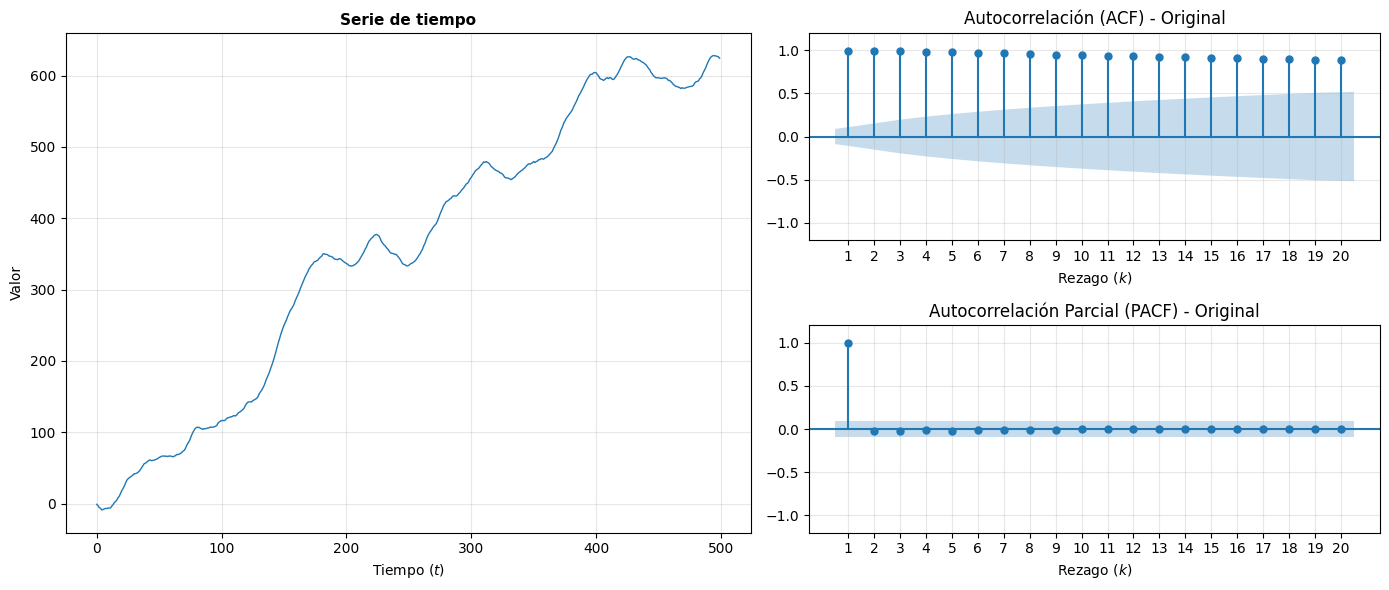

In [ ]:
lags_mostrar = 20

# Gráfico
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

# COLUMNA 1: Serie Temporal
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_arima.index, serie_arima.values, color="#1f77b4", linewidth=1)
ax1.set_title(
    r"Serie de tiempo",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): Autocorrelación (ACF)
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_arima, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Original")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (inferior): Autocorrelación Parcial (PACF)
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_arima, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Original", method="ywm"
)
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(c) Testea si la serie original es estacionaria. Usa un nivel de significancia de 5%.

In [ ]:
resultado_adf_arima = adfuller(serie_arima)

print('Resultados del Test Dickey-Fuller Aumentado para la serie original:')
print(f'Estadístico ADF: {resultado_adf_arima[0]:.4f}')
print(f'Valor p: {resultado_adf_arima[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_arima[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_arima[1] <= 0.05:
    print('La serie original es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie original no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

Resultados del Test Dickey-Fuller Aumentado para la serie original:
Estadístico ADF: -1.5779
Valor p: 0.4947
Valores críticos:
   1%: -3.4437
   5%: -2.8674
   10%: -2.5699
La serie original no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).


(d) Aplica la primera diferencia a la serie de tiempo. Grafica la serie resultante, su ACF y PACF, y testea su estacionariedad con un nivel de significancia de 5%.


Resultados del Test Dickey-Fuller Aumentado para la serie diferenciada:
Estadístico ADF: -4.5225
Valor p: 0.0002
Valores críticos:
   1%: -3.4437
   5%: -2.8674
   10%: -2.5699
La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).


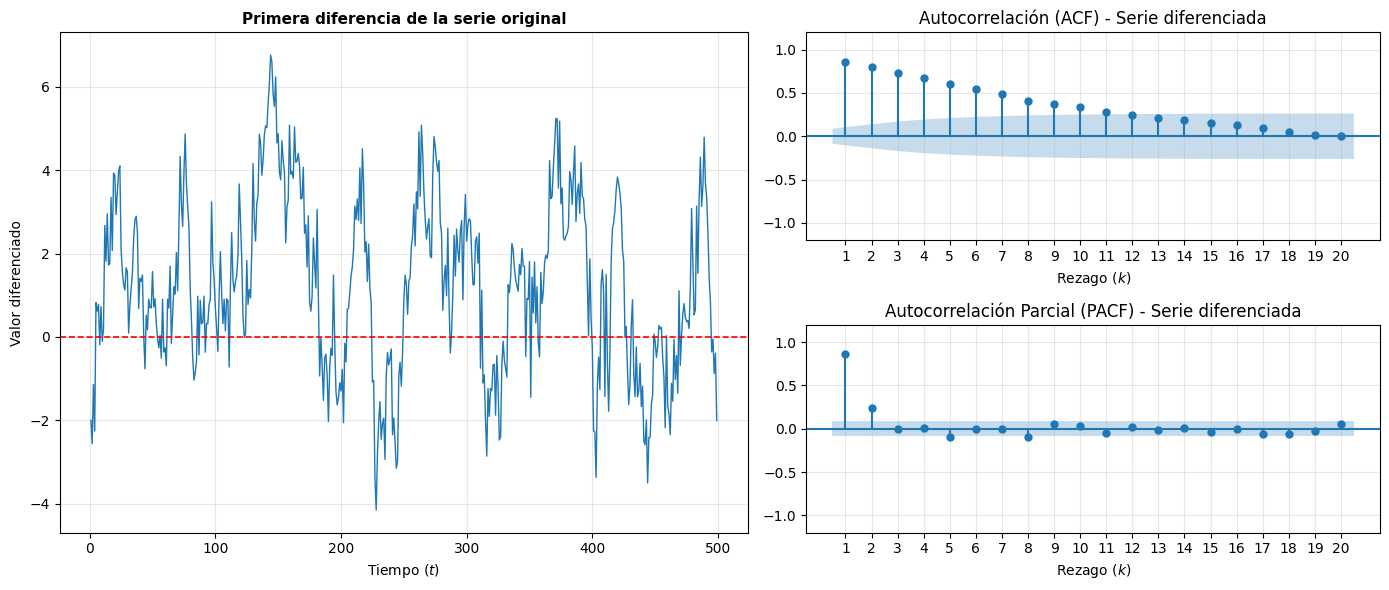

In [ ]:
# Aplicar la primera diferencia
serie_arima_diff = serie_arima.diff().dropna()

# Realizar el test ADF a la serie diferenciada
resultado_adf_arima_diff = adfuller(serie_arima_diff)

print('\nResultados del Test Dickey-Fuller Aumentado para la serie diferenciada:')
print(f'Estadístico ADF: {resultado_adf_arima_diff[0]:.4f}')
print(f'Valor p: {resultado_adf_arima_diff[1]:.4f}')
print('Valores críticos:')
for key, value in resultado_adf_arima_diff[4].items():
    print(f'   {key}: {value:.4f}')

# Interpretar el resultado
if resultado_adf_arima_diff[1] <= 0.05:
    print('La serie diferenciada es estacionaria (se rechaza la hipótesis nula de raíz unitaria).')
else:
    print('La serie diferenciada no es estacionaria (no se puede rechazar la hipótesis nula de raíz unitaria).')

# Graficar la serie diferenciada, ACF y PACF para confirmación visual
lags_mostrar = 20

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1])

ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(serie_arima_diff.index, serie_arima_diff.values, color="#1f77b4", linewidth=1)
ax1.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax1.set_title(r"Primera diferencia de la serie original", fontsize=11, fontweight="bold")
ax1.set_xlabel("Tiempo ($t$)")
ax1.set_ylabel("Valor diferenciado")
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
plot_acf(serie_arima_diff, ax=ax2, lags=lags_mostrar, zero=False, title="Autocorrelación (ACF) - Serie diferenciada")
ax2.set_xlabel("Rezago ($k$)")
ax2.set_xticks(range(1, lags_mostrar + 1))
ax2.set_ylim(-1.2, 1.2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(serie_arima_diff, ax=ax3, lags=lags_mostrar, zero=False, title="Autocorrelación Parcial (PACF) - Serie diferenciada", method="ywm")
ax3.set_xlabel("Rezago ($k$)")
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.2, 1.2)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(e) Aplica la función `auto_arima` de la librería `pmdarima` sobre la serie original ¿Qué obtienes?

In [ ]:
model_auto_arima = pm.auto_arima(serie_arima,
                                 start_p=2,
                                 # max_p=3,
                                 # d=1,             # Forzar d=1
                                 start_q=0, max_q=0,  # Forzar q=0
                                 trace=True,
                                 suppress_warnings=True,
                                 seasonal=False,
                                 information_criterion='bic',
                                 stepwise=True)

print(model_auto_arima.summary())

Performing stepwise search to minimize bic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : BIC=1431.356, Time=0.82 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=2144.490, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=1456.390, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=2296.793, Time=0.08 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : BIC=1437.565, Time=2.38 sec
 ARIMA(2,1,0)(0,0,0)[0]             : BIC=1429.532, Time=0.62 sec
 ARIMA(1,1,0)(0,0,0)[0]             : BIC=1458.384, Time=0.23 sec
 ARIMA(3,1,0)(0,0,0)[0]             : BIC=1435.710, Time=0.69 sec

Best model:  ARIMA(2,1,0)(0,0,0)[0]          
Total fit time: 5.242 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:               SARIMAX(2, 1, 0)   Log Likelihood                -705.447
Date:                Fri, 25 Sep 2026   AIC                           1416.894
Time:                        14:09:0

**Nota:**

La ecuación del proceso simulado es:

$$Y_t = 1.7 Y_{t-1} - 0.5 Y_{t-2} - 0.2 Y_{t-3} + \epsilon_t$$

Reagrupando términos para expresar la ecuación en función de sus diferencias ($\Delta Y_t = Y_t - Y_{t-1}$):

$$Y_t - Y_{t-1} = 0.7 Y_{t-1} - 0.5 Y_{t-2} - 0.2 Y_{t-3} + \epsilon_t$$

Sumando y restando términos en el lado derecho para forzar diferencias consecutivas:

$$\Delta Y_t = 0.7 Y_{t-1} - 0.7 Y_{t-2} + 0.2 Y_{t-2} - 0.2 Y_{t-3} + \epsilon_t$$

$$\Delta Y_t = 0.7 (Y_{t-1} - Y_{t-2}) + 0.2 (Y_{t-2} - Y_{t-3}) + \epsilon_t$$

$$\Delta Y_t = 0.7 \Delta Y_{t-1} + 0.2 \Delta Y_{t-2} + \epsilon_t$$
